# Random Forest Hyperparameter Tuning for Maximum F2 Score

This notebook performs an 80/20 stratified train/test split and uses GridSearchCV to find the Random Forest hyperparameters that maximize the F2 score (which weights recall more heavily than precision).


  TARGET: Machine Failure (Overall) (Machine failure)
  Positive cases: 339 / 10000
  Best threshold: 0.35  |  Val F2: 0.7358


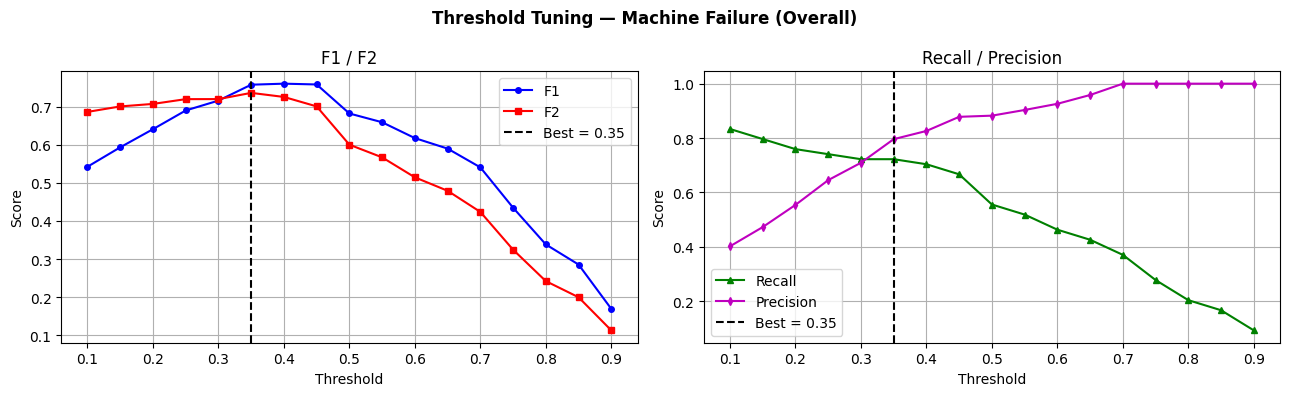

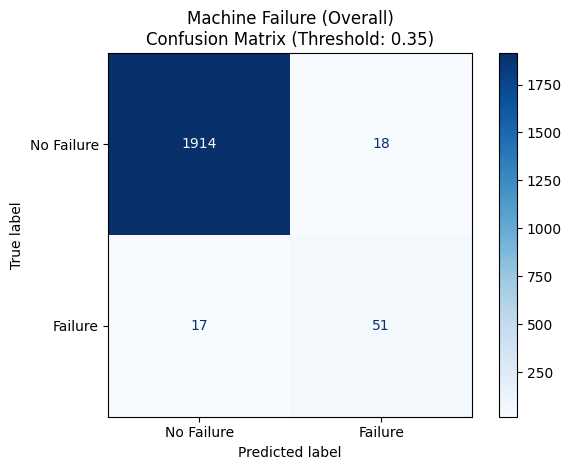

              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.74      0.75      0.74        68

    accuracy                           0.98      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.98      0.98      0.98      2000

  Precision : 0.7391
  Recall    : 0.7500
  F1 Score  : 0.7445
  F2 Score  : 0.7478
  Threshold : 0.35

  TARGET: Tool Wear Failure (TWF)
  Positive cases: 46 / 10000
  Best threshold: 0.10  |  Val F2: 0.2778


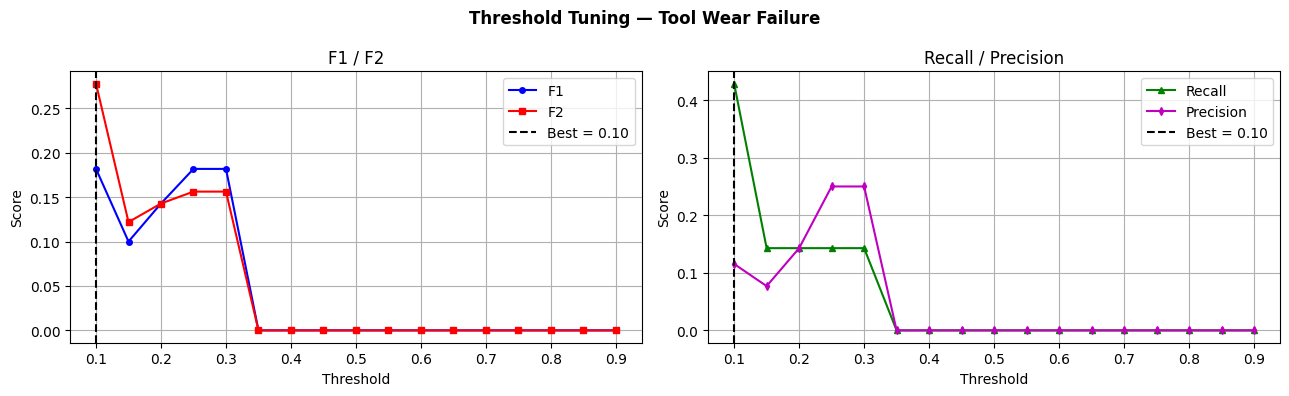

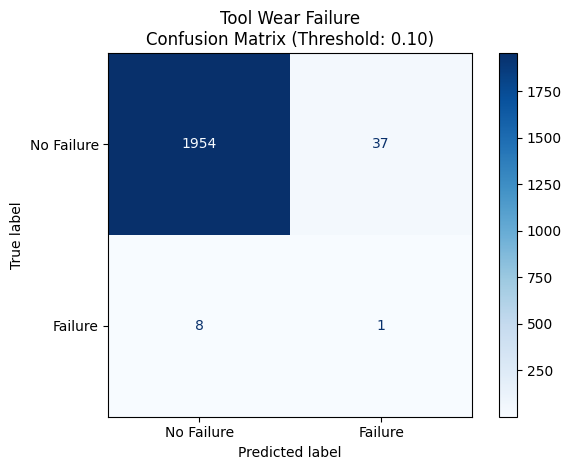

              precision    recall  f1-score   support

  No Failure       1.00      0.98      0.99      1991
     Failure       0.03      0.11      0.04         9

    accuracy                           0.98      2000
   macro avg       0.51      0.55      0.52      2000
weighted avg       0.99      0.98      0.98      2000

  Precision : 0.0263
  Recall    : 0.1111
  F1 Score  : 0.0426
  F2 Score  : 0.0676
  Threshold : 0.10

  TARGET: Heat Dissipation Failure (HDF)
  Positive cases: 115 / 10000
  Best threshold: 0.25  |  Val F2: 0.9341


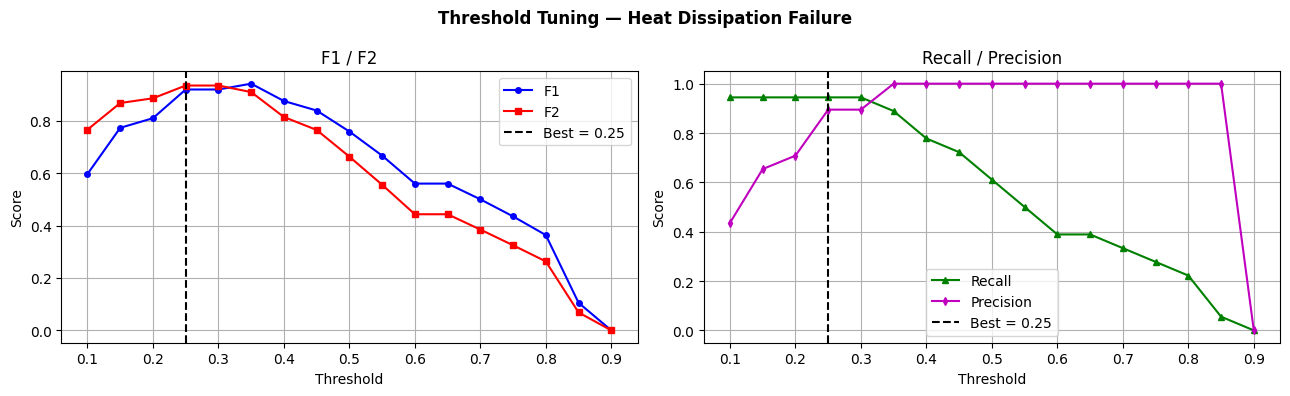

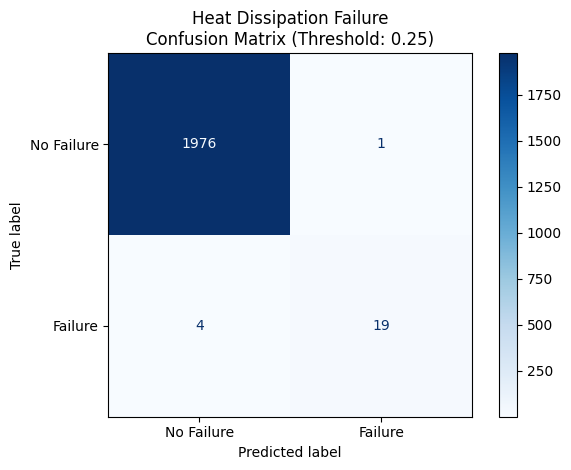

              precision    recall  f1-score   support

  No Failure       1.00      1.00      1.00      1977
     Failure       0.95      0.83      0.88        23

    accuracy                           1.00      2000
   macro avg       0.97      0.91      0.94      2000
weighted avg       1.00      1.00      1.00      2000

  Precision : 0.9500
  Recall    : 0.8261
  F1 Score  : 0.8837
  F2 Score  : 0.8482
  Threshold : 0.25

  TARGET: Power Failure (PWF)
  Positive cases: 95 / 10000
  Best threshold: 0.15  |  Val F2: 0.8025


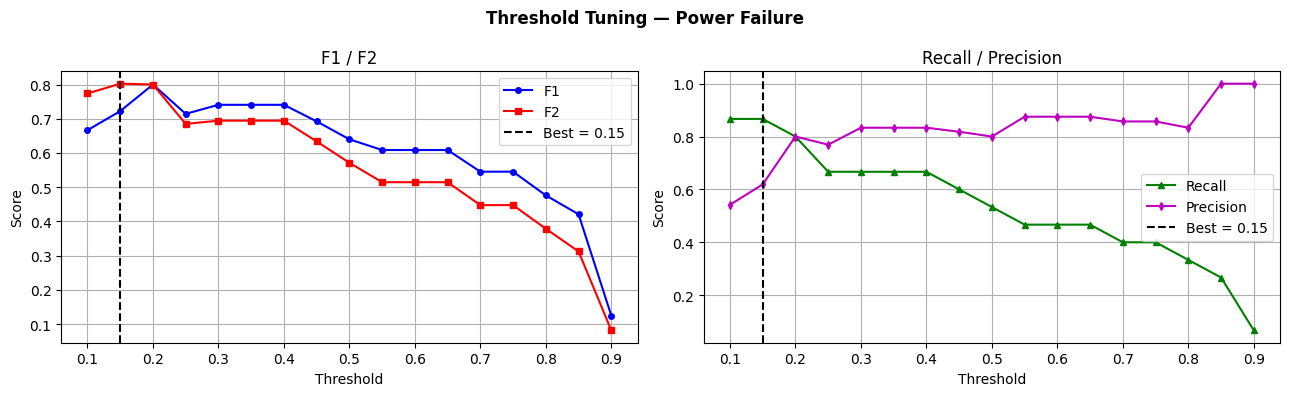

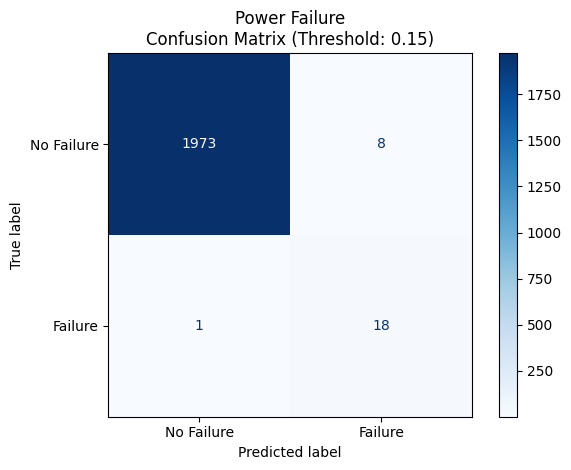

              precision    recall  f1-score   support

  No Failure       1.00      1.00      1.00      1981
     Failure       0.69      0.95      0.80        19

    accuracy                           1.00      2000
   macro avg       0.85      0.97      0.90      2000
weighted avg       1.00      1.00      1.00      2000

  Precision : 0.6923
  Recall    : 0.9474
  F1 Score  : 0.8000
  F2 Score  : 0.8824
  Threshold : 0.15

  TARGET: Overstrain Failure (OSF)
  Positive cases: 98 / 10000
  Best threshold: 0.25  |  Val F2: 0.9412


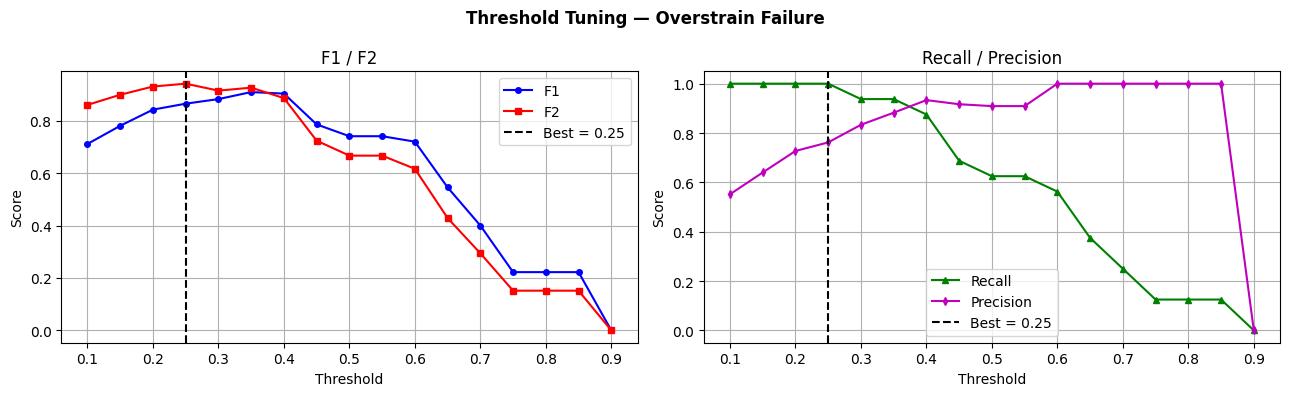

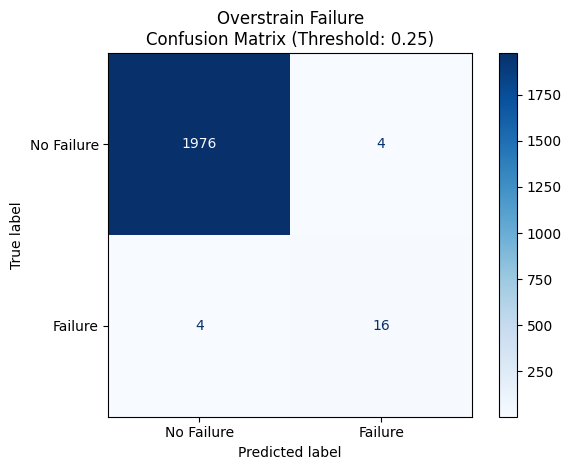

              precision    recall  f1-score   support

  No Failure       1.00      1.00      1.00      1980
     Failure       0.80      0.80      0.80        20

    accuracy                           1.00      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       1.00      1.00      1.00      2000

  Precision : 0.8000
  Recall    : 0.8000
  F1 Score  : 0.8000
  F2 Score  : 0.8000
  Threshold : 0.25

  TARGET: Random Failure (RNF)
  Positive cases: 19 / 10000
  Best threshold: 0.50  |  Val F2: 0.0000


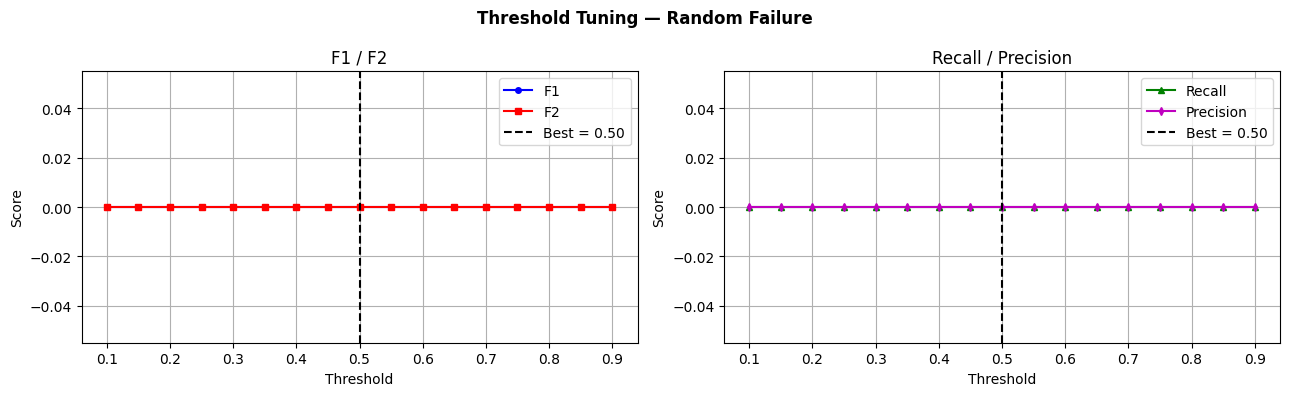

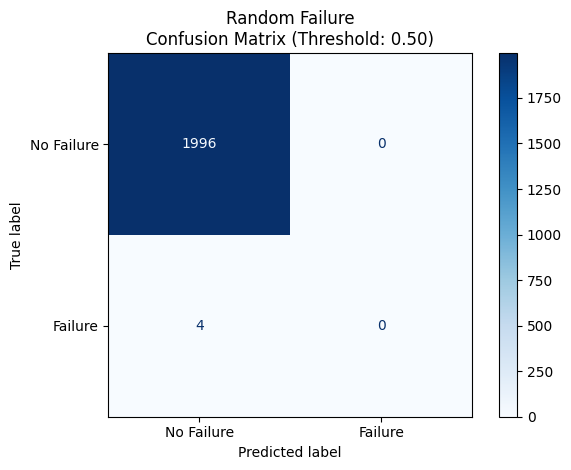

              precision    recall  f1-score   support

  No Failure       1.00      1.00      1.00      1996
     Failure       0.00      0.00      0.00         4

    accuracy                           1.00      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       1.00      1.00      1.00      2000

  Precision : 0.0000
  Recall    : 0.0000
  F1 Score  : 0.0000
  F2 Score  : 0.0000
  Threshold : 0.50

  SUMMARY — ALL FAILURE TYPES
                                      name positives threshold  precision  recall      f1      f2
Machine failure  Machine Failure (Overall)       339      0.35     0.7391  0.7500  0.7445  0.7478
TWF                      Tool Wear Failure        46       0.1     0.0263  0.1111  0.0426  0.0676
HDF               Heat Dissipation Failure       115      0.25     0.9500  0.8261  0.8837  0.8482
PWF                          Power Failure        95      0.15     0.6923  0.9474  0.8000  0.8824
OSF                     Overstrain Failure       

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, fbeta_score, recall_score,
                             precision_score, confusion_matrix,         
                             ConfusionMatrixDisplay, classification_report)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load & Prepare
df = pd.read_csv('data/ai4i2020.csv')
df.columns = df.columns.str.strip()

le = LabelEncoder()
df['Type_encoded'] = le.fit_transform(df['Type'])

feature_cols = ['Type_encoded', 'Air temperature', 'Process temperature',
                'Rotational speed', 'Torque', 'Tool wear']

failure_targets = {
    'Machine failure': 'Machine Failure (Overall)',
    'TWF': 'Tool Wear Failure',
    'HDF': 'Heat Dissipation Failure',
    'PWF': 'Power Failure',
    'OSF': 'Overstrain Failure',
    'RNF': 'Random Failure'
}

X = df[feature_cols].values
all_results = {}

for target_col, target_name in failure_targets.items():
    print(f"\n{'='*60}")
    print(f"  TARGET: {target_name} ({target_col})")
    print(f"  Positive cases: {df[target_col].sum()} / {len(df)}")
    print(f"{'='*60}")

    y = df[target_col].values

    # Skip if too few positives to stratify
    if y.sum() < 10:
        print(f"  ⚠ Too few positive cases ({y.sum()}) — skipping.")
        continue

    # Outer split: 80/20 train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Inner split: 80/20 train/val for threshold tuning
    X_train_split, X_val, y_train_split, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
    )

    # Train on inner split only
    tune_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    tune_model.fit(X_train_split, y_train_split)
    y_pred_proba_val = tune_model.predict_proba(X_val)[:, 1]

    # Threshold sweep 0.10 → 0.90 step 0.05
    thresholds = np.arange(0.10, 0.91, 0.05)
    best_threshold, best_f2_val = 0.5, 0
    threshold_list, f1_scores_val, f2_scores_val = [], [], []
    recall_scores_val, precision_scores_val = [], []

    for threshold in thresholds:
        y_pred_val = (y_pred_proba_val >= threshold).astype(int)
        threshold_list.append(round(threshold, 2))
        f1_scores_val.append(f1_score(y_val, y_pred_val, zero_division=0))
        f2_scores_val.append(fbeta_score(y_val, y_pred_val, beta=2, zero_division=0))
        recall_scores_val.append(recall_score(y_val, y_pred_val, zero_division=0))
        precision_scores_val.append(precision_score(y_val, y_pred_val, zero_division=0))
        if f2_scores_val[-1] > best_f2_val:
            best_f2_val = f2_scores_val[-1]
            best_threshold = round(threshold, 2)

    print(f"  Best threshold: {best_threshold:.2f}  |  Val F2: {best_f2_val:.4f}")

    # Threshold curves
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Threshold Tuning — {target_name}', fontsize=12, fontweight='bold')

    axes[0].plot(threshold_list, f1_scores_val, 'b-o', label='F1', markersize=4)
    axes[0].plot(threshold_list, f2_scores_val, 'r-s', label='F2', markersize=4)
    axes[0].axvline(best_threshold, color='k', linestyle='--', label=f'Best = {best_threshold:.2f}')
    axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
    axes[0].set_title('F1 / F2'); axes[0].legend(); axes[0].grid(True)

    axes[1].plot(threshold_list, recall_scores_val, 'g-^', label='Recall', markersize=4)
    axes[1].plot(threshold_list, precision_scores_val, 'm-d', label='Precision', markersize=4)
    axes[1].axvline(best_threshold, color='k', linestyle='--', label=f'Best = {best_threshold:.2f}')
    axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Score')
    axes[1].set_title('Recall / Precision'); axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    # Retrain on full training data
    final_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    final_model.fit(X_train, y_train)
    y_pred_final = (final_model.predict_proba(X_test)[:, 1] >= best_threshold).astype(int)

    # Confusion matrix
    cm_final = confusion_matrix(y_test, y_pred_final)
    ConfusionMatrixDisplay(cm_final, display_labels=['No Failure', 'Failure']).plot(cmap=plt.cm.Blues)
    plt.title(f'{target_name}\nConfusion Matrix (Threshold: {best_threshold:.2f})')
    plt.tight_layout(); plt.show()

    # Metrics
    p  = precision_score(y_test, y_pred_final, zero_division=0)
    r  = recall_score(y_test, y_pred_final, zero_division=0)
    f1 = f1_score(y_test, y_pred_final, zero_division=0)
    f2 = fbeta_score(y_test, y_pred_final, beta=2, zero_division=0)

    print(classification_report(y_test, y_pred_final,
                                target_names=['No Failure', 'Failure'], zero_division=0))
    print(f"  Precision : {p:.4f}")
    print(f"  Recall    : {r:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  F2 Score  : {f2:.4f}")
    print(f"  Threshold : {best_threshold:.2f}")

    all_results[target_col] = {
        'name': target_name, 'positives': int(df[target_col].sum()),
        'threshold': best_threshold,
        'precision': p, 'recall': r, 'f1': f1, 'f2': f2
    }

print(f"\n{'='*60}")
print("  SUMMARY — ALL FAILURE TYPES")
print(f"{'='*60}")
summary_df = pd.DataFrame(all_results).T
summary_df = summary_df[['name', 'positives', 'threshold', 'precision', 'recall', 'f1', 'f2']]
summary_df[['precision','recall','f1','f2']] = summary_df[['precision','recall','f1','f2']].astype(float).round(4)
print(summary_df.to_string(index=True))